# 02 · The LAD-FLEX method & per-scenario computation

**LAD-FLEX** (Latency-Aware Deferrable Flexibility) decides, for a given
flexibility window `[t1, t2]`, which tasks can be shifted into it. A task is
*deferrable* when:

1. it is **latency-tolerant** — `wait_time >= λ̂` (latency threshold);
2. it fits inside the **whiskered window** `[t0, tend]`, where
   `t0 = t1 − δ` (notification period) and `tend = t2 + γ` (buffer);
3. it does not **overhang** `[t1, t2]` by more than a fraction `β` of its runtime
   on either side.

The function below is `LAD_flex` from `lad_flex.py`. We then run it across an
hourly grid of flexibility windows for three grid-service scenarios:
**BASELINE**, **DAM** (displayed as *Intraday*) and **mFRR**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import os
from lad_flex import *

sns.set_theme(style="whitegrid")
os.makedirs("outputs", exist_ok=True)

# task_name is kept as the index so each task has a stable identity (used in notebook 04)
df = pd.read_csv("data/df_tasks_sample.csv", parse_dates=["start_time", "end_time"]).set_index("task_name")
df["t_request"] = df["start_time"] - pd.to_timedelta(df["wait_time"], unit="s")

# Total DC power/energy series (the denominator for "% flexible"). Computed once.
df_power_energy = fast_power_energy_series(df, get_timeline(df))
print("tasks:", len(df), "| total DC energy (full slice): %.0f kWh" % df_power_energy["energy_kWh"].sum())

tasks: 100000 | total DC energy (full slice): 13763 kWh


## A single flexibility window, step by step

BASELINE parameters, one window on 1970-02-04. Green = notification period, red = flexibility window, blue step = power of the tasks LAD-FLEX would defer.

window 1970-02-04 18:00:00 -> 1970-02-04 21:00:00
deferrable tasks: 30 | not deferrable: 286


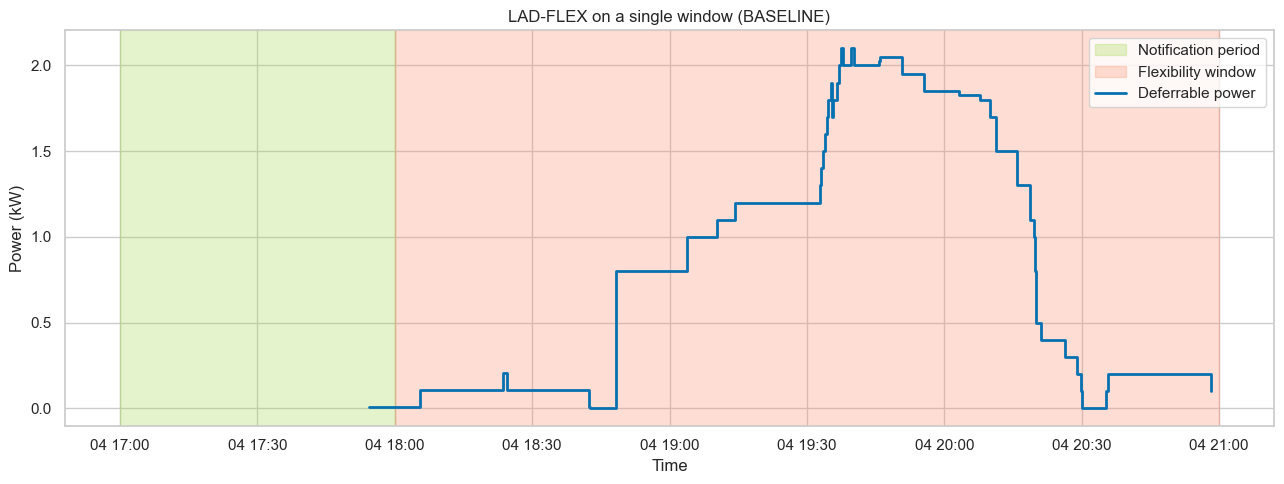

In [2]:
p = return_params("DEFAULT", "BASELINE")
lat, fw = p["latencies"][0], p["flex_windows"][0]
dn, beta, gb = p["delta_notifications"][0], p["betas"][0], p["gamma_buffers"][0]

t1 = pd.Timestamp("1970-02-04 18:00"); t2 = t1 + fw
t0, tend = t1 - dn, t2 + gb

max_rt = (dn + fw + gb).total_seconds()
df_scen = df[df["runtime_i"] <= max_rt]
df_def, df_nd = LAD_flex(df_scen, lat, t1, t2, beta, dn, gb)
print("window", t1, "->", t2)
print("deferrable tasks:", len(df_def), "| not deferrable:", len(df_nd))

fig, ax = plt.subplots(figsize=(13, 5))
ax.axvspan(t0, t1, color="#A6D854", alpha=0.3, label="Notification period")
ax.axvspan(t1, t2, color="#FC9272", alpha=0.3, label="Flexibility window")
if len(df_def):
    pe = fast_power_energy_series(df_def, get_timeline(df_def)).loc[t0:tend]
    ax.step(pe.index, pe["power_kW"], where="post", color="#0571B0", lw=2, label="Deferrable power")
ax.set_xlabel("Time"); ax.set_ylabel("Power (kW)")
ax.set_title("LAD-FLEX on a single window (BASELINE)"); ax.legend()
plt.tight_layout(); plt.show()

## Full hourly sweep over the sample week (3 scenarios)

`run_lad_flex_sweep` runs `LAD_flex` for every (parameter combination × hourly
window) and assembles `df_summary` (KPIs) and `res_dfs` (detailed per-window
DataFrames). Results are cached to `outputs/` for notebooks 03 and 04.

In [3]:
SCENARIOS = ["BASELINE", "DAM", "mFRR"]
sample_week = pd.date_range("1970-02-01", "1970-02-08", freq="h")  # 169 hourly windows

results = {}
for scen in SCENARIOS:
    p = return_params("DEFAULT", scen)
    mr = (max(p["delta_notifications"]) + max(p["flex_windows"]) + max(p["gamma_buffers"])).total_seconds()
    ds, res = run_lad_flex_sweep(df[df["runtime_i"] <= mr], df_power_energy, sample_week, p)
    pts = compute_notable_points(ds)
    results[scen] = {"params": p, "df_summary": ds, "res_dfs": res, "points": pts}
    joblib.dump(ds, f"outputs/df_summary_{scen}.joblib")
    joblib.dump(res, f"outputs/res_dfs_{scen}.joblib")
    joblib.dump(pts, f"outputs/points_{scen}.joblib")
    print(f"{scen:9s}: mean deferrable {ds['deferrable_energy_kWh'].mean():6.1f} kWh | "
          f"mean %flexible {ds['percentage_flexible_energy'].mean():5.1f}%")

BASELINE : mean deferrable    6.6 kWh | mean %flexible   3.2%


DAM      : mean deferrable   10.1 kWh | mean %flexible   3.6%


mFRR     : mean deferrable    0.5 kWh | mean %flexible   0.8%


## Deferrable energy over time + notable windows

For each scenario we mark nine notable windows: **P1–P3** (highest deferrable
energy), **Q1–Q3** (around the 75th percentile) and **R1–R3** (around the median).

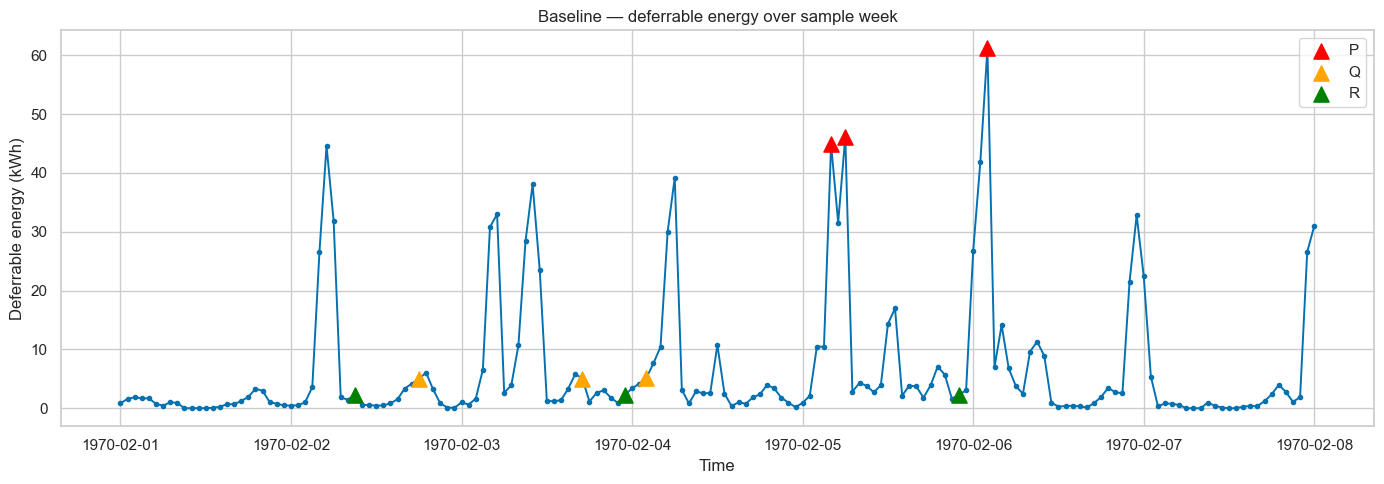

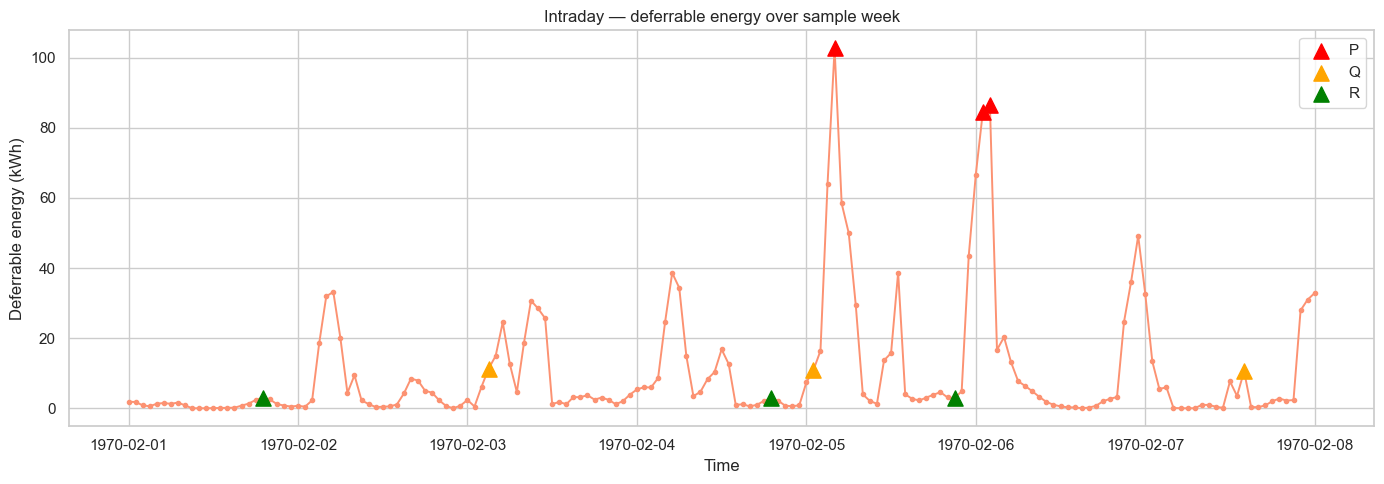

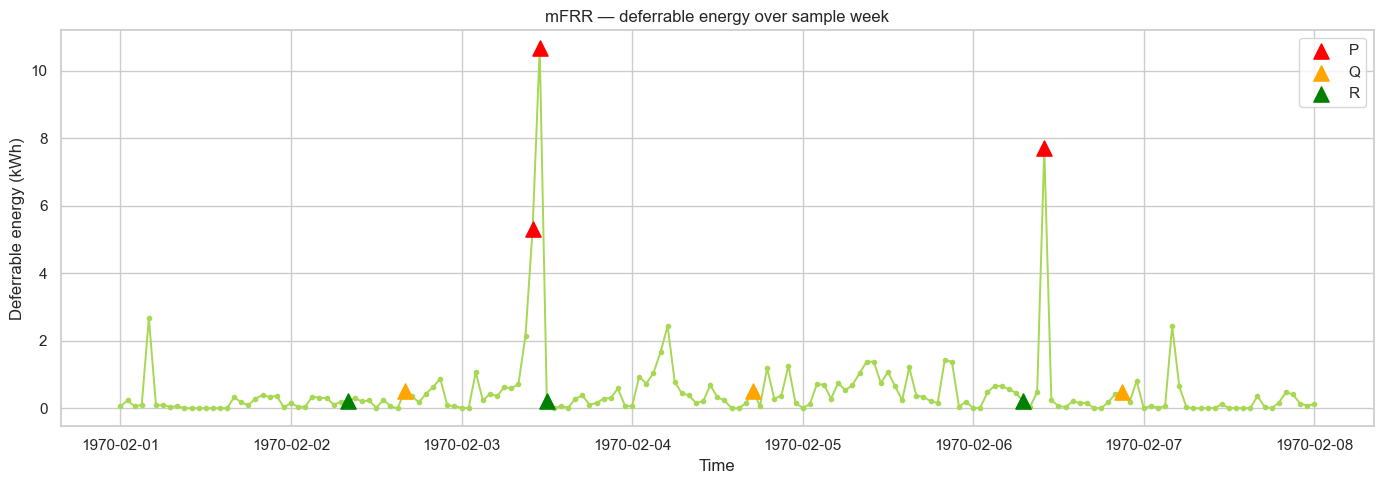

In [4]:
def plot_deferrable_with_points(scen):
    r = results[scen]
    s = deferrable_energy_timeseries(r["df_summary"])
    pts = r["points"]
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(s.index, s.values, marker="o", ms=3, color=SCENARIO_COLORS[scen], lw=1.4)
    for grp, c, lab in [(["p1", "p2", "p3"], "red", "P"),
                        (["q1", "q2", "q3"], "orange", "Q"),
                        (["r1", "r2", "r3"], "green", "R")]:
        ax.scatter([pts[k] for k in grp], [s[pts[k]] for k in grp],
                   color=c, marker="^", s=120, zorder=5, label=lab)
    ax.set_title(f"{SCENARIO_DISPLAY[scen]} — deferrable energy over sample week")
    ax.set_xlabel("Time"); ax.set_ylabel("Deferrable energy (kWh)"); ax.legend()
    plt.tight_layout(); plt.savefig(f"outputs/deferrable_energy_{scen}.png", dpi=150); plt.show()

for scen in SCENARIOS:
    plot_deferrable_with_points(scen)

## 3×3 deferred-power grid for the notable windows (BASELINE)

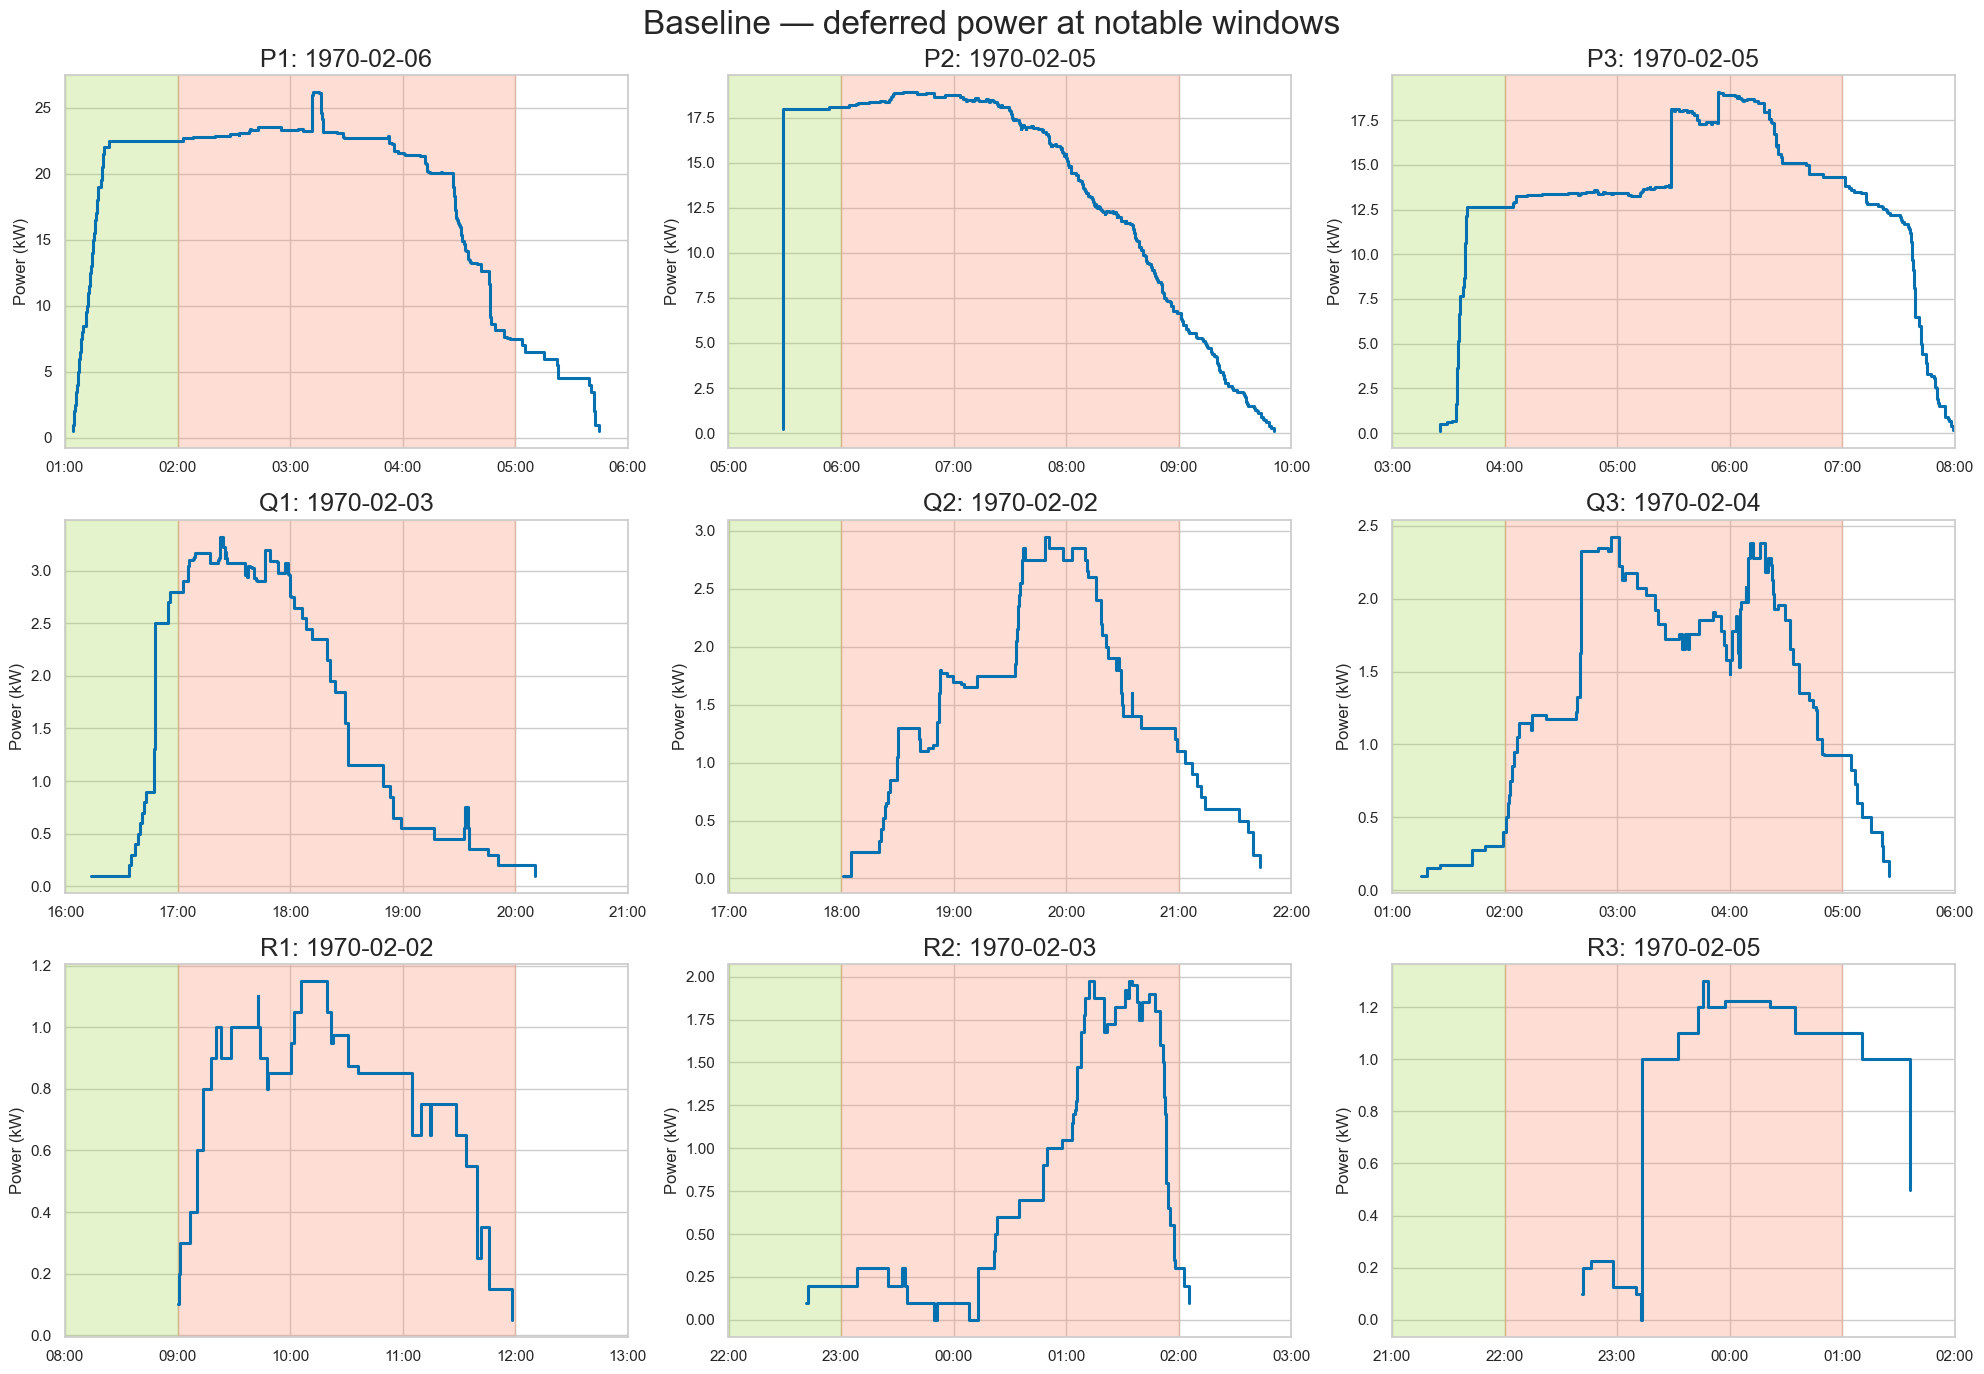

In [5]:
def plot_3x3(scen):
    r = results[scen]; pts = r["points"]; res = r["res_dfs"]; p = r["params"]
    lat = p["latencies"][0]; fw = p["flex_windows"][0]; dn = p["delta_notifications"][0]
    beta = p["betas"][0]; gb = p["gamma_buffers"][0]
    names = ["p1", "p2", "p3", "q1", "q2", "q3", "r1", "r2", "r3"]
    fig, axs = plt.subplots(3, 3, figsize=(20, 14))
    for i, nm in enumerate(names):
        ax = axs[i // 3, i % 3]
        d = res[(pts[nm], lat, fw, dn, beta, gb)]
        ax.axvspan(d["t0"], d["t1"], color="#A6D854", alpha=0.3)
        ax.axvspan(d["t1"], d["t2"], color="#FC9272", alpha=0.3)
        pw = d["df_t0_to_tend_def"].power_kW
        ax.step(pw.index, pw.values, where="post", color="#0571B0", lw=2.2)
        ax.set_title(f"{nm.upper()}: {pts[nm].date()}", fontsize=18)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.set_xlim(d["t0"].floor("h"), d["tend"].ceil("h"))
        ax.set_ylabel("Power (kW)")
    fig.suptitle(f"{SCENARIO_DISPLAY[scen]} — deferred power at notable windows", fontsize=24)
    plt.tight_layout(); plt.savefig(f"outputs/power_3x3_{scen}.png", dpi=150); plt.show()

plot_3x3("BASELINE")

## Before / after: reshaping the DC load (P1 of each scenario)

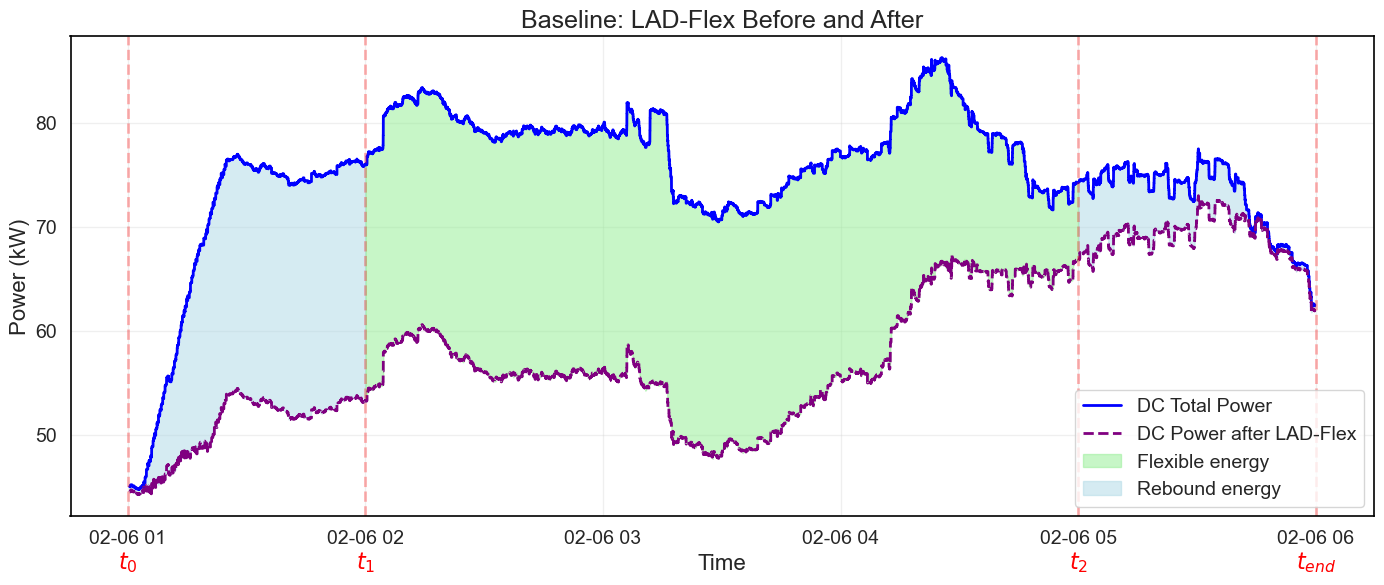

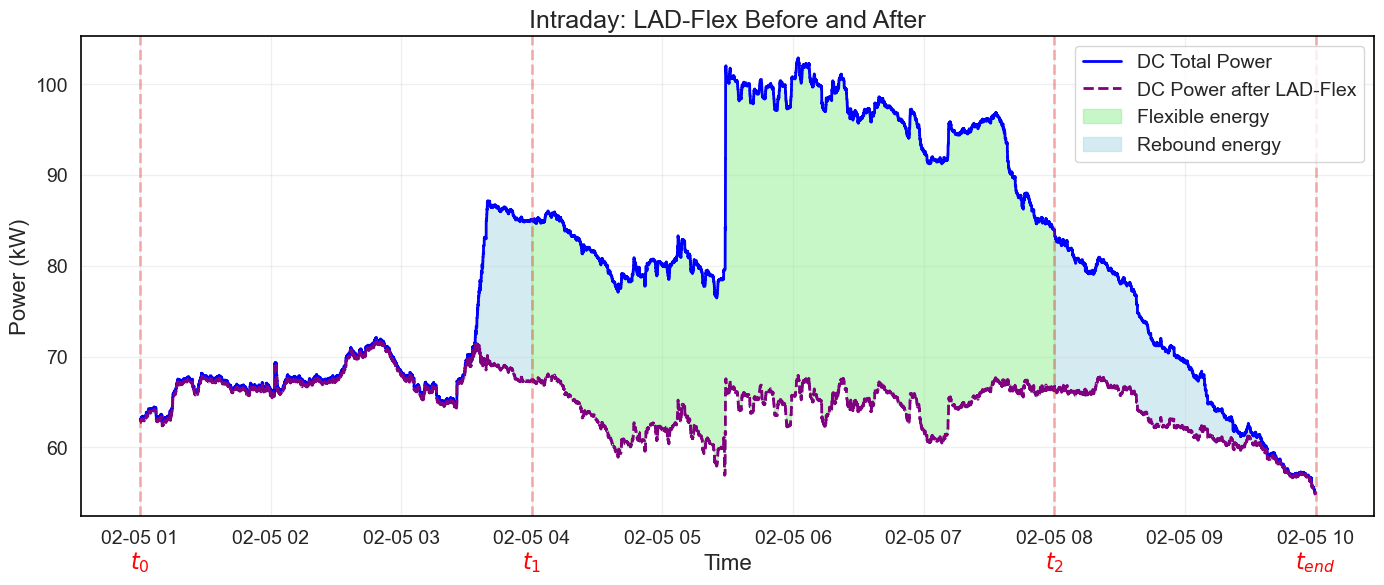

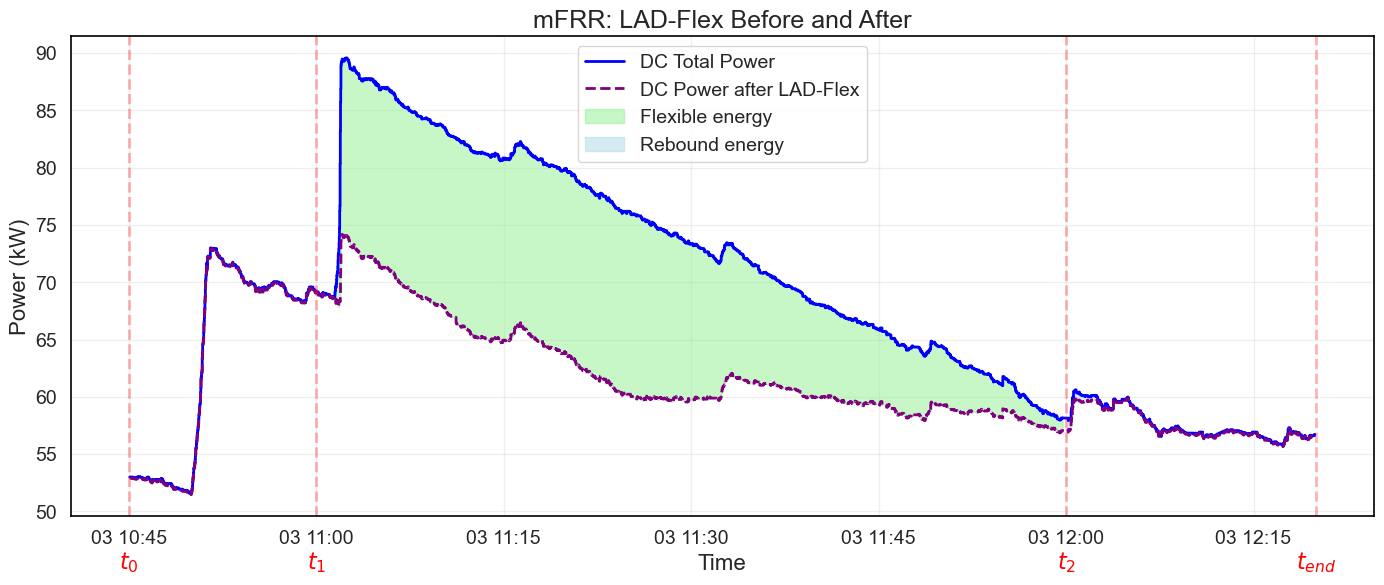

In [6]:
for scen in SCENARIOS:
    r = results[scen]; p = r["params"]
    plot_ladflex_before_after(
        "p1", r["points"], r["res_dfs"], p["latencies"],
        p["flex_windows"][0], p["delta_notifications"][0],
        p["betas"][0], p["gamma_buffers"][0],
        save_path=f"outputs/before_after_{scen}.png",
        title_string=SCENARIO_DISPLAY[scen],
    )

## Breakdown table at notable windows

In [7]:
rows = []
for scen in SCENARIOS:
    ds = results[scen]["df_summary"]; pts = results[scen]["points"]; p = results[scen]["params"]
    key0 = (p["latencies"][0], p["flex_windows"][0], p["delta_notifications"][0],
            p["betas"][0], p["gamma_buffers"][0])
    for nm in ["p1", "q1", "r1"]:
        d = ds.loc[(pts[nm],) + key0]
        rows.append({
            "scenario": SCENARIO_DISPLAY[scen], "point": nm.upper(),
            "tasks": int(d["deferrable_task_count"]),
            "deferrable_kWh": round(d["deferrable_energy_kWh"], 1),
            "total_kWh": round(d["total_energy_kWh"], 1),
            "pct_flexible": round(d["percentage_flexible_energy"], 1),
        })
tab = pd.DataFrame(rows)
tab.to_csv("outputs/breakdown_table.csv", index=False)
tab

,scenario,point,tasks,deferrable_kWh,total_kWh,pct_flexible
0,Baseline,P1,95,61.2,233.6,26.2
1,Baseline,Q1,53,5.0,140.4,3.6
2,Baseline,R1,18,2.3,150.7,1.5
3,Intraday,P1,245,102.6,361.1,28.4
4,Intraday,Q1,63,10.9,291.1,3.7
5,Intraday,R1,15,2.9,167.6,1.7
6,mFRR,P1,181,10.7,73.1,14.6
7,mFRR,Q1,29,0.5,68.2,0.7
8,mFRR,R1,7,0.2,60.4,0.4


Per-scenario summaries (`df_summary_*.joblib`), detailed results
(`res_dfs_*.joblib`) and notable points (`points_*.joblib`) are now cached in
`outputs/`. Next: **`03_scenario_comparison.ipynb`**.